# Software per riconoscimento di frutta esotica


## Importazione delle librerie utili

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

## Caricamento del dataset

In [52]:
RANDOM_SEED = 0
url = " https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv" 
df = pd.read_csv(url)
df.head()
df.head()

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
0,Mela,86.40,89.68,8.69,9.61,2.41
1,Mela,77.58,73.45,6.49,7.20,3.87
2,Mela,81.95,81.66,6.40,9.09,2.88
3,Mela,66.33,36.71,6.78,8.21,2.55
4,Mela,56.73,75.69,5.78,9.15,3.88


## Preprocessing dei dati

In [53]:
print("Valori mancanti per colonna:")
print(df.isnull().sum())

Valori mancanti per colonna:
Frutto                   0
Peso (g)                 0
Diametro medio (mm)      0
Lunghezza media (mm)     0
Durezza buccia (1-10)    0
Dolcezza (1-10)          0
dtype: int64


In [54]:
print("Descrizione del dataset:")
print(df.describe())

Descrizione del dataset:
         Peso (g)  Diametro medio (mm)  Lunghezza media (mm)  \
count  500.000000           500.000000            500.000000   
mean    47.313440            86.573100              5.298620   
std     26.768797            64.293403              2.641993   
min      8.570000             7.530000              1.150000   
25%     24.797500            50.510000              2.672500   
50%     42.380000            70.450000              5.670000   
75%     68.080000            88.852500              7.455000   
max    111.210000           299.890000             11.140000   

       Durezza buccia (1-10)  Dolcezza (1-10)  
count             500.000000       500.000000  
mean                7.437640         3.593220  
std                 1.812548         1.264899  
min                 3.070000         1.250000  
25%                 6.152500         2.570000  
50%                 7.340000         3.535000  
75%                 8.615000         4.465000  
max           

Analizzo la distribuzione delle features

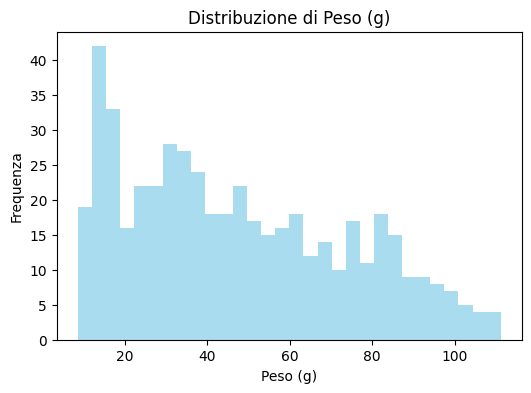

Skewness di Peso (g):
0.4532315883184722


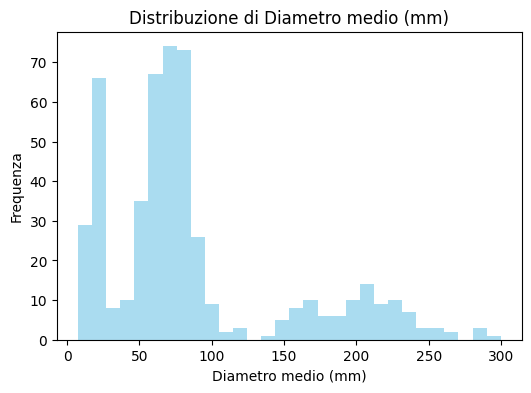

Skewness di Diametro medio (mm):
1.2668580657362953


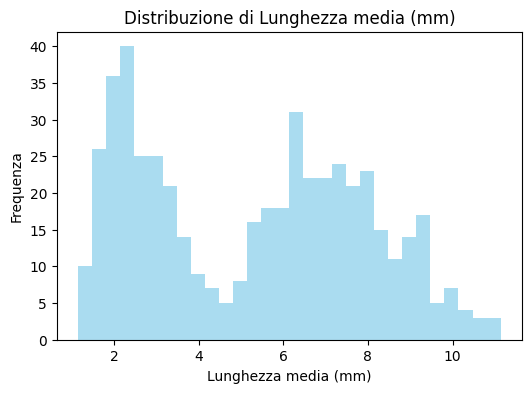

Skewness di Lunghezza media (mm):
0.11739612696850424


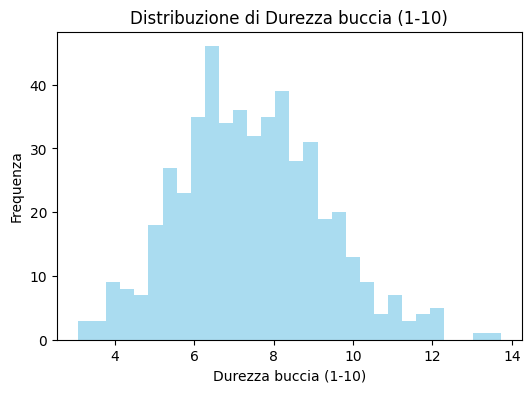

Skewness di Durezza buccia (1-10):
0.30567814003274707


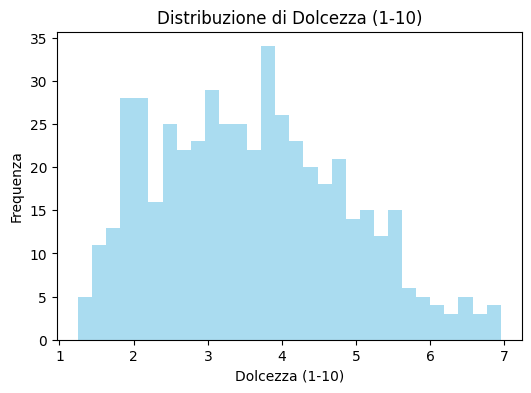

Skewness di Dolcezza (1-10):
0.3416544930474916


In [55]:
features = [
    'Peso (g)',
    'Diametro medio (mm)',
    'Lunghezza media (mm)',     
    'Durezza buccia (1-10)',    
    'Dolcezza (1-10)']
      
for feature in features:
    plt.figure(figsize=(6, 4))
    df[feature].hist(bins=30, color='skyblue', alpha=0.7)
    plt.title(f"Distribuzione di {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequenza")
    plt.grid()
    plt.show()
    skewness = df[feature].skew()
    print(f"Skewness di {feature}:")
    print(skewness)

Attraverso la skewness si nota che "Peso (g)" e "Diametro medio (mm)" sono leggermente asimmetrici a destra, mentre "Lunghezza media (mm)", "Durezza buccia (1-10)" e "Dolcezza (1-10)" sono quasi simmetrici. Potremmo provare con una trasformazione logaritmica sul Diametro medio e con una radice quadrata sul Peso(essendo l'assimetria di quest'ultimo più moderata la radice quadrata potrebbe funzionare meglio).

In [56]:
df['Peso (g)'] = np.log1p(df['Peso (g)'])
df['Diametro medio (mm)'] = np.sqrt(df['Diametro medio (mm)'])

provo la ristampa delle distribuzioni modificate

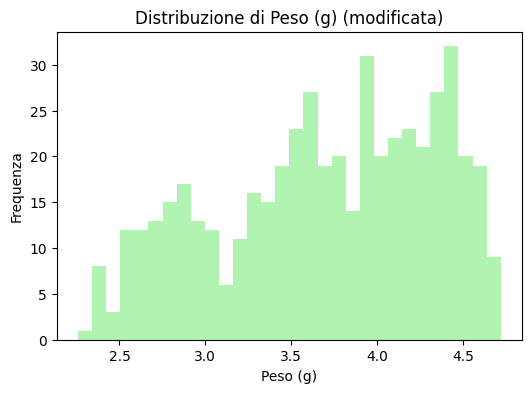

Skewness di Peso (g) (modificata):
-0.36118431699952475


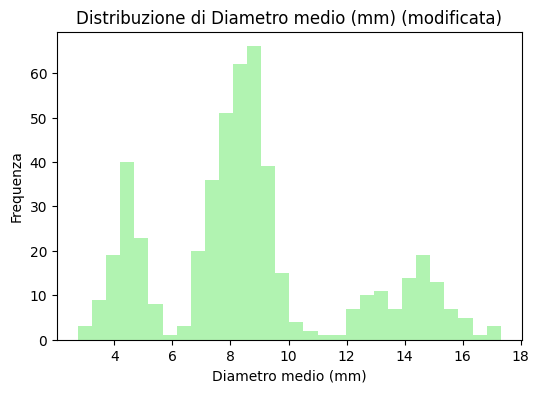

Skewness di Diametro medio (mm) (modificata):
0.5814187209704329


In [57]:
for feature in ['Peso (g)', 'Diametro medio (mm)']:
    plt.figure(figsize=(6, 4))
    df[feature].hist(bins=30, color='lightgreen', alpha=0.7)
    plt.title(f"Distribuzione di {feature} (modificata)")
    plt.xlabel(feature)
    plt.ylabel("Frequenza")
    plt.grid()
    plt.show()
    skewness = df[feature].skew()
    print(f"Skewness di {feature} (modificata):")
    print(skewness)

## Divisione dei set di dati e normalizzazione

In [58]:
X = df[features]
y = df['Frutto']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)       

## Addestramento del modello KNN

Per decidere quale k utilizzare, possiamo provare diversi valori e vedere quale dà la migliore accuratezza sul set di test.

In [60]:
Ks = [1, 2, 3, 4, 5, 10, 15, 20, 40, 50]

for k in Ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred_train = knn.predict(X_train)
    y_proba_train = knn.predict_proba(X_train)

    y_pred_test = knn.predict(X_test)
    y_proba_test = knn.predict_proba(X_test)

    log_train = log_loss(y_train, y_proba_train)
    log_test = log_loss(y_test, y_proba_test)

    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    print(f"K = {k:>2}  ACCURACY: TRAIN={accuracy_train:.3f}: TEST={accuracy_test:.3f}  LOGLOSS: TRAIN={log_train:.3f}: TEST={log_test:.3f}")

K =  1  ACCURACY: TRAIN=1.000: TEST=0.900  LOGLOSS: TRAIN=0.000: TEST=3.604
K =  2  ACCURACY: TRAIN=0.965: TEST=0.830  LOGLOSS: TRAIN=0.050: TEST=2.246
K =  3  ACCURACY: TRAIN=0.958: TEST=0.870  LOGLOSS: TRAIN=0.101: TEST=1.577
K =  4  ACCURACY: TRAIN=0.943: TEST=0.850  LOGLOSS: TRAIN=0.112: TEST=0.895
K =  5  ACCURACY: TRAIN=0.943: TEST=0.860  LOGLOSS: TRAIN=0.126: TEST=0.537
K = 10  ACCURACY: TRAIN=0.938: TEST=0.870  LOGLOSS: TRAIN=0.160: TEST=0.222
K = 15  ACCURACY: TRAIN=0.932: TEST=0.890  LOGLOSS: TRAIN=0.173: TEST=0.203
K = 20  ACCURACY: TRAIN=0.935: TEST=0.900  LOGLOSS: TRAIN=0.185: TEST=0.198
K = 40  ACCURACY: TRAIN=0.935: TEST=0.900  LOGLOSS: TRAIN=0.224: TEST=0.229
K = 50  ACCURACY: TRAIN=0.940: TEST=0.900  LOGLOSS: TRAIN=0.239: TEST=0.244


#### Cross-Validation

In [61]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
k_values = [1, 2, 3, 4, 5, 10, 15, 20, 40, 50]
results = {}

for k in k_values:
    accuracies = []
    log_losses = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_train_cv, X_val_cv = X_train[train_idx], X_train[val_idx]
        y_train_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_cv, y_train_cv)
        y_pred = knn.predict(X_val_cv)
        y_proba = knn.predict_proba(X_val_cv)
        
        acc = accuracy_score(y_val_cv, y_pred)
        logloss = log_loss(y_val_cv, y_proba)
        accuracies.append(acc)
        log_losses.append(logloss)
    
    results[k] = {
        'accuracy': np.mean(accuracies),
        'log_loss': np.mean(log_losses)
    }
    print(f"K = {k:>2}, Accuracy media: {results[k]['accuracy']:.4f}, Log-loss media: {results[k]['log_loss']:.4f}")

best_k = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nMiglior valore di k: {best_k}, Accuracy: {results[best_k]['accuracy']:.4f}, Log-loss: {results[best_k]['log_loss']:.4f}")

K =  1, Accuracy media: 0.8975, Log-loss media: 3.6945
K =  2, Accuracy media: 0.8800, Log-loss media: 1.9807
K =  3, Accuracy media: 0.9150, Log-loss media: 1.2832
K =  4, Accuracy media: 0.9100, Log-loss media: 0.9479
K =  5, Accuracy media: 0.9150, Log-loss media: 0.7806
K = 10, Accuracy media: 0.9275, Log-loss media: 0.6119
K = 15, Accuracy media: 0.9250, Log-loss media: 0.3700
K = 20, Accuracy media: 0.9250, Log-loss media: 0.3836
K = 40, Accuracy media: 0.9250, Log-loss media: 0.2497
K = 50, Accuracy media: 0.9250, Log-loss media: 0.2732

Miglior valore di k: 10, Accuracy: 0.9275, Log-loss: 0.6119


Sceglieremo k=10 essendo il miglior valore trovato con cross-validation.

In [62]:
best_k = 10 
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [63]:
y_pred_test = final_knn.predict(X_test)
y_proba_test = final_knn.predict_proba(X_test)

accuracy_test = accuracy_score(y_test, y_pred_test)
logloss_test = log_loss(y_test, y_proba_test)

print(f"Accuracy sul test set: {accuracy_test:.4f}")
print(f"Log-loss sul test set: {logloss_test:.4f}")

cm = confusion_matrix(y_test, y_pred_test)
print("\nMatrice di confusione:")
print(cm)


Accuracy sul test set: 0.8700
Log-loss sul test set: 0.2219

Matrice di confusione:
[[17  0  3  1  0]
 [ 0 19  0  0  0]
 [ 6  0 12  0  0]
 [ 2  0  1 14  0]
 [ 0  0  0  0 25]]


Provo ad usare meodo KNN ma con pesi sulle distanze per vedere se le gli errori sulle classi vicine diminuiscono.

In [64]:
cv_dist = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
k_values = [1, 2, 3, 4, 5, 10, 15, 20, 40, 50]
results = {}

print("=== CV: KNN (pesi = distanze) ===")
for k in k_values:
    accs, logs = [], []
    for tr, va in cv.split(X_train, y_train):
        X_tr, X_va = X_train[tr], X_train[va]
        y_tr, y_va = y_train.iloc[tr], y_train.iloc[va]
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
        knn.fit(X_tr, y_tr)
        y_va_pred = knn.predict(X_va)
        y_va_proba = knn.predict_proba(X_va)
        accs.append(accuracy_score(y_va, y_va_pred))
        logs.append(log_loss(y_va, y_va_proba))
    results[k] = {'acc_mean': np.mean(accs), 'log_mean': np.mean(logs)}
    print(f"K={k:>2}  acc_media={results[k]['acc_mean']:.4f}  log_media={results[k]['log_mean']:.4f}")

best_k_dist = max(results, key=lambda k: results[k]['acc_mean'])
print(f"\nMiglior k (pesi = distanze): {best_k_dist}  "
      f"acc={results[best_k_dist]['acc_mean']:.4f}  log={results[best_k_dist]['log_mean']:.4f}")


final_knn_dist = KNeighborsClassifier(n_neighbors=best_k_dist, weights='distance')
final_knn_dist.fit(X_train, y_train)

y_pred_test_dist = final_knn_dist.predict(X_test)
y_proba_test_dist = final_knn_dist.predict_proba(X_test)

acc_test_dist = accuracy_score(y_test, y_pred_test_dist)
log_test_dist = log_loss(y_test, y_proba_test_dist)
cm_dist = confusion_matrix(y_test, y_pred_test_dist)

print("\n=== Test: KNN (pesi =distanze) ===")
print(f"Accuracy: {acc_test_dist:.4f}")
print(f"Log-loss: {log_test_dist:.4f}")
print("Matrice di confusione:")
print(cm_dist)

=== CV: KNN (pesi = distanze) ===
K= 1  acc_media=0.8975  log_media=3.6945
K= 2  acc_media=0.8975  log_media=1.9727
K= 3  acc_media=0.9175  log_media=1.2772
K= 4  acc_media=0.9175  log_media=0.9394
K= 5  acc_media=0.9225  log_media=0.7713
K=10  acc_media=0.9275  log_media=0.6040
K=15  acc_media=0.9275  log_media=0.3637
K=20  acc_media=0.9325  log_media=0.3746
K=40  acc_media=0.9325  log_media=0.2366
K=50  acc_media=0.9300  log_media=0.2546

Miglior k (pesi = distanze): 40  acc=0.9325  log=0.2366

=== Test: KNN (pesi =distanze) ===
Accuracy: 0.9000
Log-loss: 0.2220
Matrice di confusione:
[[17  0  2  2  0]
 [ 0 19  0  0  0]
 [ 4  0 14  0  0]
 [ 0  0  2 15  0]
 [ 0  0  0  0 25]]


Il metodo con i pesi delle distanze sembra migliorare leggermente le prestazioni del modello, come evidenziato dai valori di accuracy e log-loss sul set di test.   

Faccio ulteriori due prove utilizzando le distanze di Manhattan e Minkowski

In [65]:
cv_manhattan = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
k_values = [1, 2, 3, 4, 5, 10, 15, 20, 40, 50]
results_manhattan = {}

print("=== CV: KNN (metrica = Manhattan) ===")
for k in k_values:
    accs, logs = [], []
    for tr, va in cv_manhattan.split(X_train, y_train):
        X_tr, X_va = X_train[tr], X_train[va]
        y_tr, y_va = y_train.iloc[tr], y_train.iloc[va]
        knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
        knn.fit(X_tr, y_tr)
        y_va_pred = knn.predict(X_va)
        y_va_proba = knn.predict_proba(X_va)
        accs.append(accuracy_score(y_va, y_va_pred))
        logs.append(log_loss(y_va, y_va_proba))
    results_manhattan[k] = {'acc_mean': np.mean(accs), 'log_mean': np.mean(logs)}
    print(f"K={k:>2}  acc_media={results_manhattan[k]['acc_mean']:.4f}  log_media={results_manhattan[k]['log_mean']:.4f}")

best_k_manhattan = max(results_manhattan, key=lambda k: results_manhattan[k]['acc_mean'])
print(f"\nMiglior k (metrica = Manhattan): {best_k_manhattan}  "
      f"acc={results_manhattan[best_k_manhattan]['acc_mean']:.4f}  log={results_manhattan[best_k_manhattan]['log_mean']:.4f}")


final_knn_manhattan = KNeighborsClassifier(n_neighbors=best_k_manhattan, metric='manhattan')
final_knn_manhattan.fit(X_train, y_train)

y_pred_test_manhattan = final_knn_manhattan.predict(X_test)
y_proba_test_manhattan = final_knn_manhattan.predict_proba(X_test)

acc_test_manhattan = accuracy_score(y_test, y_pred_test_manhattan)
log_test_manhattan = log_loss(y_test, y_proba_test_manhattan)
cm_manhattan = confusion_matrix(y_test, y_pred_test_manhattan)

print("\n=== Test: KNN (metrica = Manhattan) ===")
print(f"Accuracy: {acc_test_manhattan:.4f}")
print(f"Log-loss: {log_test_manhattan:.4f}")
print("Matrice di confusione:")
print(cm_manhattan)

=== CV: KNN (metrica = Manhattan) ===
K= 1  acc_media=0.9050  log_media=3.4241
K= 2  acc_media=0.8775  log_media=1.7121
K= 3  acc_media=0.8950  log_media=1.1227
K= 4  acc_media=0.9175  log_media=0.9460
K= 5  acc_media=0.9250  log_media=0.8625
K=10  acc_media=0.9200  log_media=0.6144
K=15  acc_media=0.9250  log_media=0.4545
K=20  acc_media=0.9225  log_media=0.2968
K=40  acc_media=0.9325  log_media=0.2467
K=50  acc_media=0.9300  log_media=0.2626

Miglior k (metrica = Manhattan): 40  acc=0.9325  log=0.2467

=== Test: KNN (metrica = Manhattan) ===
Accuracy: 0.9300
Log-loss: 0.2271
Matrice di confusione:
[[17  0  2  2  0]
 [ 0 19  0  0  0]
 [ 2  0 16  0  0]
 [ 1  0  0 16  0]
 [ 0  0  0  0 25]]


In [66]:
# === CV: KNN (metrica = Minkowski, vari p) ===
cv_minkowski = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
k_values = [1, 2, 3, 4, 5, 10, 15, 20, 40, 50]
p=3

results_minkowski = []

print("=== CV: KNN (metrica = Minkowski) ===")

for k in k_values:
    accs, logs = [], []
    for tr, va in cv_minkowski.split(X_train, y_train):
        X_tr, X_va = X_train[tr], X_train[va]
        y_tr, y_va = y_train.iloc[tr], y_train.iloc[va]
        knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=p)
        knn.fit(X_tr, y_tr)
        y_va_pred = knn.predict(X_va)
        y_va_proba = knn.predict_proba(X_va)
        accs.append(accuracy_score(y_va, y_va_pred))
        logs.append(log_loss(y_va, y_va_proba))
    results_minkowski.append({
        'p': p,
        'k': k,
        'acc_mean': np.mean(accs),
        'log_mean': np.mean(logs)
    })
    print(f"p={p}  K={k:>2}  acc_media={np.mean(accs):.4f}  log_media={np.mean(logs):.4f}")

best_combo = max(results_minkowski, key=lambda r: r['acc_mean'])
print(f"\nMiglior combinazione Minkowski: p={best_combo['p']}  K={best_combo['k']}  "
      f"acc={best_combo['acc_mean']:.4f}  log={best_combo['log_mean']:.4f}")


final_knn_minkowski = KNeighborsClassifier(n_neighbors=best_combo['k'],
                                           metric='minkowski', p=best_combo['p'])
final_knn_minkowski.fit(X_train, y_train)

y_pred_test_minkowski = final_knn_minkowski.predict(X_test)
y_proba_test_minkowski = final_knn_minkowski.predict_proba(X_test)

acc_test_minkowski = accuracy_score(y_test, y_pred_test_minkowski)
log_test_minkowski = log_loss(y_test, y_proba_test_minkowski)
cm_minkowski = confusion_matrix(y_test, y_pred_test_minkowski)

print("\n=== Test: KNN (metrica = Minkowski) ===")
print(f"Accuracy: {acc_test_minkowski:.4f}")
print(f"Log-loss: {log_test_minkowski:.4f}")
print("Matrice di confusione:")
print(cm_minkowski)

=== CV: KNN (metrica = Minkowski) ===
p=3  K= 1  acc_media=0.9000  log_media=3.6044
p=3  K= 2  acc_media=0.8775  log_media=2.1540
p=3  K= 3  acc_media=0.9125  log_media=1.1976
p=3  K= 4  acc_media=0.9100  log_media=1.0297
p=3  K= 5  acc_media=0.9125  log_media=0.8668
p=3  K=10  acc_media=0.9250  log_media=0.6146
p=3  K=15  acc_media=0.9300  log_media=0.3731
p=3  K=20  acc_media=0.9225  log_media=0.3840
p=3  K=40  acc_media=0.9250  log_media=0.2629
p=3  K=50  acc_media=0.9125  log_media=0.2939

Miglior combinazione Minkowski: p=3  K=15  acc=0.9300  log=0.3731

=== Test: KNN (metrica = Minkowski) ===
Accuracy: 0.9300
Log-loss: 0.2085
Matrice di confusione:
[[18  0  2  1  0]
 [ 0 19  0  0  0]
 [ 2  0 16  0  0]
 [ 0  0  2 15  0]
 [ 0  0  0  0 25]]


Sembra che la metrica Manhattan abbia portato il risultato migliore, avendo ridotto gli errori tra classi simili, ma mantenendo Accurcay e Log-Loss buone.

#### Learning curve del miglior modello (Manhattan)

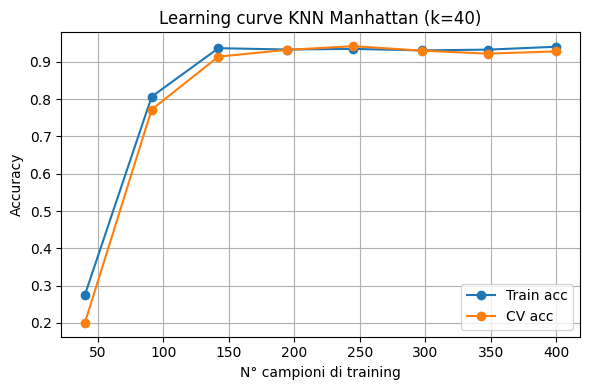

In [67]:
k = best_k_manhattan
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=k, metric='manhattan'))
])

train_sizes = np.linspace(0.1, 1.0, 8)
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

sizes, tr_scores, val_scores = learning_curve(
    estimator=pipe, X=X, y=y,
    train_sizes=train_sizes, cv=cv_lc,
    n_jobs=-1, shuffle=True, random_state=RANDOM_SEED
)

tr_mean, val_mean = tr_scores.mean(axis=1), val_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(sizes, tr_mean, 'o-', color='tab:blue', label='Train acc')
plt.plot(sizes, val_mean, 'o-', color='tab:orange', label='CV acc')
plt.title(f"Learning curve KNN Manhattan (k={k})")
plt.xlabel("N° campioni di training")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()